# Decision Tree

## Introduction

This notebook continues the modeling workflow for predicting customer churn by introducing a decision tree model as a flexible, non-linear alternative to logistic regression.

In the previous stage, logistic regression was used to establish an interpretable baseline and to identify the primary drivers of churn under a linear modeling assumption. While this approach provides valuable insights, it assumes that the relationship between predictors and churn risk is linear on the log-odds scale and that interactions must be specified explicitly.

A decision tree relaxes these assumptions by learning non-linear relationships and interactions directly from the data. Instead of estimating coefficients, the model partitions the feature space into segments using a series of hierarchical decision rules. Each split is chosen to improve the homogeneity of the target variable within the resulting groups, allowing the model to capture complex patterns without requiring manual specification of interactions or transformations.

Unlike earlier exploratory approaches that considered discretization of continuous variables, the model in this notebook operates directly on continuous features. Decision trees inherently learn optimal split thresholds, making manual binning unnecessary and allowing the model to preserve the full information contained in the original variables.

From an interpretability perspective, decision trees provide a different type of explanation compared to logistic regression. Rather than global coefficients, the model represents churn risk through a set of local decision paths, where each path corresponds to a sequence of conditions leading to a predicted outcome or probability.

The objective of this stage is to evaluate whether this additional flexibility leads to improved predictive performance, particularly in terms of capturing non-linear effects and interactions. At the same time, we assess the trade-off between flexibility and model stability, as decision trees are known to be prone to overfitting.

To ensure a fair comparison with the baseline model, the same evaluation framework is retained. Model training and hyperparameter tuning are performed using cross-validation within the training data, while a separate validation set is used to guide model selection and control overfitting. A final hold-out test set is reserved exclusively for unbiased performance evaluation.

As in the previous notebook, the focus is not only on classification accuracy but on producing reliable probability estimates and ranking customers by churn risk. Evaluation metrics such as ROC-AUC, PR-AUC, and threshold-based measures are used consistently across models.

The results of this notebook will provide a non-linear benchmark and serve as a foundation for more advanced tree-based methods, such as random forests and gradient boosting models, which aim to improve stability and predictive performance.

## Table of Contents

1. [Modeling Considerations](#modeling-considerations)
2. [Model Definition and Hyperparameter Tuning](#model-definition-and-hyperparameter-tuning)
3. [Model Implementation](#model-implementation)
   - [Initial Grid Search](#initial-grid-definition-and-cross-validation)
   - [Refining Grid Search](#refining-the-hyperparameter-grid)
   - [Further Refinment of Grid](#further-refinement-of-the-hyperparameter-grid)
   - [Hyperparameter Tuning Results](#hyperparameter-tuning-results)
   - [Tree Interpretation](#tree-interpretation)
4. [Test Set Evaluation](#test-set-evaluation)
5. [Executive Summary](#executive-summary)

## Modeling Considerations

Before fitting the decision tree model, we outline several key considerations that influence model behavior and evaluation.

---

### Class Imbalance

The target variable exhibits moderate class imbalance, with approximately 26.5% of customers churning.

Decision trees can be sensitive to class imbalance during training. Since splits are chosen to optimize impurity reduction (e.g., Gini or entropy), the model may favor partitions that primarily improve classification of the majority class. In practice, this can result in high overall accuracy while failing to adequately identify churners.

To address this, accuracy is not used as a primary evaluation metric. Instead, we focus on recall, precision, F1 score, and PR-AUC, which better reflect performance on the minority class. In addition, tree complexity is explicitly controlled to avoid degenerate solutions that overfit majority-class patterns without improving minority-class detection.

---

### Feature Scaling

Decision trees do not require feature scaling. Since splits are based on thresholding individual features rather than distance-based calculations, the scale of the variables does not affect model behavior.

As a result, all features are used in their original form, simplifying preprocessing and maintaining consistency with the overall data preparation pipeline.

---

### Feature Representation

Decision trees naturally handle non-linear relationships and interaction effects, reducing the need for manual feature engineering. Variables that required explicit transformations or interaction terms in logistic regression can be modeled directly through hierarchical splits.

Continuous variables are retained in their original form. The tree model learns optimal split thresholds directly from the data, making manual discretization unnecessary and avoiding potential information loss.

The simplified integer-based representations of service-related features are also retained, as they provide a compact and efficient feature space while preserving the underlying signal.

---

### Model Complexity and Overfitting

Decision trees are highly flexible models and can easily overfit the training data if left unconstrained. Deep trees may capture noise rather than meaningful patterns, leading to poor generalization performance.

To mitigate this, model complexity is controlled through parameters such as maximum depth, minimum samples per leaf, and minimum samples required for splits. These act as regularization mechanisms, helping to balance model flexibility with stability.

---

### Validation Strategy and Iterative Model Refinement

Hyperparameter tuning and model refinement are performed iteratively, which introduces a risk of overfitting to evaluation data if not properly controlled. While cross-validation provides robust estimates of model performance within the training data, repeated use of the same data for model comparison and refinement can lead to optimistic bias.

To address this, the training data is further split into a dedicated training subset and a separate validation set. Cross-validation is applied within the training subset to evaluate candidate hyperparameter configurations, while the validation set is used to guide model refinement and select the final model.

This separation ensures that model selection decisions are not based on the same data used for model fitting, reducing the risk of selection bias. A final hold-out test set is reserved exclusively for unbiased performance evaluation and is not used at any stage of model tuning.

---

### Summary

Compared to logistic regression, decision trees relax many structural assumptions, allowing the model to capture non-linear relationships and interaction effects directly from the data. However, this increased flexibility introduces a higher risk of overfitting and sensitivity to class imbalance.

The modeling approach therefore emphasizes controlled model complexity, careful validation strategy, and appropriate evaluation metrics, ensuring that observed performance reflects genuine predictive capability rather than artifacts of model flexibility.

With these considerations in place, we proceed to defining and training the decision tree model.


## Model Definition and Hyperparameter Tuning

The decision tree model is implemented using the `DecisionTreeClassifier` from scikit-learn. Unlike logistic regression, where model structure is defined explicitly through feature specification, decision trees rely on hyperparameters to control model complexity and learning behavior.

Key hyperparameters include the maximum depth of the tree, the minimum number of samples required for a split, and the minimum number of samples required in each leaf. These parameters act as regularization mechanisms, limiting the growth of the tree and reducing the risk of overfitting to the training data.

To identify an appropriate model configuration, hyperparameters are explored using grid search combined with cross-validation. This approach evaluates multiple combinations of parameter values across different data splits within the training subset, providing a stable estimate of relative model performance and reducing sensitivity to a particular data partition.

Given the class imbalance in the dataset, model comparison is based on PR-AUC (average precision), which focuses on the model's ability to correctly rank and identify churners. This metric is more informative than accuracy and complements ROC-AUC by emphasizing performance on the minority class.

Importantly, cross-validation is used as an internal model comparison tool rather than the final decision criterion. Because hyperparameter tuning is performed iteratively, relying solely on cross-validation results can lead to optimistic bias. To mitigate this, candidate models identified through cross-validation are evaluated on a separate validation set, which is used to guide final hyperparameter selection.

This two-stage approach separates model exploration from model selection, helping to ensure that the chosen configuration generalizes beyond the data used during tuning. The final model will subsequently be evaluated on a hold-out test set to obtain an unbiased estimate of performance.

In the following section, we define the hyperparameter grid and perform cross-validated model exploration.

## Model Implementation

This section implements the decision tree modeling workflow described above, translating the conceptual approach into a reusable and consistent pipeline.

Unlike logistic regression, decision trees do not rely on linear relationships or explicitly specified interaction terms. Instead, they learn non-linear patterns and interaction effects directly through recursive partitioning of the feature space.

In contrast to earlier exploratory approaches, the model operates directly on the same feature representation used across the pipeline. Continuous variables are retained in their original form, allowing the tree to learn optimal split thresholds directly from the data without the need for manual discretization. This simplifies the preprocessing pipeline and ensures consistency across modeling approaches.

Categorical variables are encoded using one-hot encoding to ensure compatibility with the modeling framework. While decision trees are less sensitive to encoding choices than linear models, they still require numerical input. The chosen representation provides a simple and consistent feature space while allowing the model to learn category-specific splits where relevant.

The training and test datasets are loaded and prepared using the shared data preparation pipeline. Since decision trees are insensitive to feature scaling, no additional transformations are required beyond the predefined feature engineering steps.

Model training is performed using the `DecisionTreeClassifier` from scikit-learn. In contrast to the statistical approach used in logistic regression, model complexity is controlled through hyperparameters such as maximum depth and minimum samples per leaf.

To identify an appropriate model specification, hyperparameters are explored using cross-validation within the training subset. This replaces the stepwise simplification process used in logistic regression and provides a systematic approach to comparing candidate configurations.

Because hyperparameter tuning is performed iteratively, cross-validation is used as an internal model comparison tool rather than the final selection criterion. Candidate models identified through cross-validation are subsequently evaluated on a separate validation set, which is used to select the final model configuration.

The implementation proceeds in the following steps:

1. Load training, validation, and test data
2. Apply the data preparation pipeline
3. Define target and predictor variables
4. Define the decision tree model
5. Perform hyperparameter exploration using cross-validation on the training subset
6. Evaluate candidate models on the validation set and select the final configuration
7. Retrain the selected model on the combined training data (optional)
8. Evaluate final performance on the test set

We begin by loading the data.


In [31]:
import polars as pl
from sklearn.model_selection import train_test_split

# Load datasets
train_df = pl.read_csv("./data/processed/06_dpp_train_df.csv")
test_df = pl.read_csv("./data/processed/06_dpp_test_df.csv")

selected_cols = [
    'SeniorCitizenRelevel',
    'Partner',
    'Dependents',
    'tenure',
    'Contract',
    'PaperlessBilling',
    'MonthlyCharges',
    'Churn',
    'AdditionalInternetServicesCount',
    'StreamingServicesCount',
    'PaymentMethod_bin_3'
]

train_df = train_df.select(selected_cols)
test_df = test_df.select(selected_cols)

# Convert to pandas for sklearn
train_pd = train_df.to_pandas()

# Stratified split: 25% of current train -> validation
train_sub_pd, val_pd = train_test_split(
    train_pd,
    test_size=0.25,
    stratify=train_pd["Churn"],
    random_state=42
)

# Back to polars
train_sub_df = pl.from_pandas(train_sub_pd)
val_df = pl.from_pandas(val_pd)

# Shapes
print("Train subset shape:", train_sub_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Class proportions helper
def class_proportions(df, name):
    print(f"\n{name} class proportions:")
    print(
        df.group_by("Churn")
        .len()
        .with_columns(
            (pl.col("len") / pl.col("len").sum()).alias("proportion")
        )
        .sort("Churn")
    )

class_proportions(train_sub_df, "Train subset")
class_proportions(val_df, "Validation")
class_proportions(test_df, "Test")

Train subset shape: (4225, 11)
Validation shape: (1409, 11)
Test shape: (1409, 11)

Train subset class proportions:
shape: (2, 3)
┌───────┬──────┬────────────┐
│ Churn ┆ len  ┆ proportion │
│ ---   ┆ ---  ┆ ---        │
│ str   ┆ u32  ┆ f64        │
╞═══════╪══════╪════════════╡
│ No    ┆ 3104 ┆ 0.734675   │
│ Yes   ┆ 1121 ┆ 0.265325   │
└───────┴──────┴────────────┘

Validation class proportions:
shape: (2, 3)
┌───────┬──────┬────────────┐
│ Churn ┆ len  ┆ proportion │
│ ---   ┆ ---  ┆ ---        │
│ str   ┆ u32  ┆ f64        │
╞═══════╪══════╪════════════╡
│ No    ┆ 1035 ┆ 0.734564   │
│ Yes   ┆ 374  ┆ 0.265436   │
└───────┴──────┴────────────┘

Test class proportions:
shape: (2, 3)
┌───────┬──────┬────────────┐
│ Churn ┆ len  ┆ proportion │
│ ---   ┆ ---  ┆ ---        │
│ str   ┆ u32  ┆ f64        │
╞═══════╪══════╪════════════╡
│ No    ┆ 1035 ┆ 0.734564   │
│ Yes   ┆ 374  ┆ 0.265436   │
└───────┴──────┴────────────┘


The datasets are now loaded and partitioned into training, validation, and test sets. We proceed by preparing the data, ensuring consistent encoding and feature representation across all splits.

In [32]:
from src.utils.data_preparation_models import prepare_tree_features

In [ ]:
categorical_cols = ['SeniorCitizenRelevel',
                    'Partner',
                    'Dependents',
                    'Contract',
                    'PaperlessBilling',
                    'PaymentMethod_bin_3']

target_col = "Churn"

numerical_cols = ['tenure', 
                  'MonthlyCharges', 
                  'AdditionalInternetServicesCount', 
                  'StreamingServicesCount']   

categorical_orders = { "SeniorCitizenRelevel": ["No", "Yes"], 
                      "Partner": ["No", "Yes"], 
                      "Dependents": ["No", "Yes"], 
                      "PaperlessBilling": ["No", "Yes"], 
                      "Contract": ["Month-to-month", "One year", "Two year"] }

train_X, train_y = prepare_tree_features(
    df=train_sub_df,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col
)

validation_X, validation_y = prepare_tree_features(
    df=val_df,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col,
    reference_columns=train_X.columns.tolist()
)

In [34]:
print(train_X.shape)
print(validation_X.shape)

(4225, 18)
(1409, 18)


Categorical variables are one-hot encoded to provide a fully numeric input matrix for the model.

Some features created during feature engineering are represented as short-range integer variables. These are retained as ordinal numeric features rather than being one-hot encoded. Preserving their ordering allows the decision tree to learn threshold-based splits directly, which is a core aspect of its learning mechanism.

The resulting design matrix therefore consists of a combination of one-hot encoded categorical variables, ordinal integer features, and continuous variables, providing a flexible feature space capable of capturing both discrete and continuous patterns in the data.

### Initial Grid Definition and Cross-Validation

The decision tree model is initially explored using cross-validated grid search to identify promising regions of the hyperparameter space. This approach evaluates multiple configurations of model complexity across different data splits within the training subset, providing a stable estimate of relative model performance and reducing sensitivity to a single data partition.

Model comparison during this stage is based on PR-AUC (average precision), which is well-suited for imbalanced classification problems and emphasizes the model’s ability to correctly rank and identify churners.

The hyperparameter grid is designed to explore a range of tree complexities, with particular focus on maximum depth, minimum samples per split, and minimum samples per leaf. These parameters control the growth of the tree and act as regularization mechanisms.

At this stage, cross-validation is used as an internal model comparison tool rather than the final selection criterion. Candidate configurations identified through cross-validation will be further evaluated on a separate validation set to guide final model selection.

The tuning process therefore balances model flexibility and generalization performance, aiming to identify configurations that capture meaningful structure in the data while remaining stable across validation folds.

In [35]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20],
    "criterion": ["gini", "entropy"]
}

### Hyperparameter Grid Design

The hyperparameter grid for the decision tree model is designed to explore a range of tree complexities while maintaining control over overfitting.

---

#### Tree Depth (`max_depth`)

The maximum depth parameter controls how many hierarchical splits the tree is allowed to make.

Values of 3, 5, 7, and 10 are included, together with `None` to allow unrestricted growth. Shallower trees provide stronger regularization and may generalize better, while deeper trees allow the model to capture more complex non-linear relationships and interactions. The inclusion of an unconstrained depth allows assessment of the model’s tendency to overfit when no explicit limitation is imposed.

---

#### Minimum Samples per Leaf (`min_samples_leaf`)

This parameter defines the minimum number of observations required in each terminal node.

Values of 1, 5, 10, and 20 are considered. Larger values enforce smoother decision boundaries by preventing the formation of very small leaf nodes, which are often associated with noise and instability in the model.

---

#### Minimum Samples for Split (`min_samples_split`)

This parameter determines the minimum number of observations required for a node to be eligible for splitting.

Values of 2, 10, and 20 are explored. Lower values allow the tree to grow more freely, potentially capturing fine-grained patterns, while higher values act as a regularization mechanism by restricting unnecessary splits and improving generalization.

---

#### Split Criterion (`criterion`)

The split criterion defines how the quality of a split is evaluated.

Both Gini impurity and entropy are considered. These criteria measure node impurity in slightly different ways but often produce similar results in practice. Including both allows for empirical comparison and ensures that model performance is not sensitive to the choice of impurity measure.

---

### Summary

The grid focuses on controlling model complexity through depth and node-size constraints while allowing flexibility to capture non-linear relationships. By exploring both constrained and unconstrained configurations, the tuning process evaluates the trade-off between model expressiveness and overfitting.

This structured search provides a robust basis for selecting a decision tree that balances predictive performance and generalization.


Run cross validation on grid search

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid.fit(train_X, train_y)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

Extract the best candidates to validate

In [37]:
import pandas as pd

cv_results = pd.DataFrame(grid.cv_results_)

cv_summary = (
    cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

cv_summary.head(10)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
0,1,0.610231,0.039025,0.702882,"{'criterion': 'entropy', 'max_depth': 7, 'min_..."
1,1,0.610231,0.039025,0.702882,"{'criterion': 'entropy', 'max_depth': 7, 'min_..."
2,1,0.610231,0.039025,0.702882,"{'criterion': 'entropy', 'max_depth': 7, 'min_..."
3,4,0.608308,0.047159,0.704401,"{'criterion': 'gini', 'max_depth': 7, 'min_sam..."
4,4,0.608308,0.047159,0.704401,"{'criterion': 'gini', 'max_depth': 7, 'min_sam..."
5,4,0.608308,0.047159,0.704401,"{'criterion': 'gini', 'max_depth': 7, 'min_sam..."
6,7,0.608092,0.042497,0.649949,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."
7,7,0.608092,0.042497,0.649949,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."
8,7,0.608092,0.042497,0.649949,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."
9,10,0.605529,0.038737,0.651815,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."


In [38]:
top_candidates = cv_summary.drop_duplicates(subset=["mean_test_score", "std_test_score", "mean_train_score"]).head(5)

top_candidates

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
0,1,0.610231,0.039025,0.702882,"{'criterion': 'entropy', 'max_depth': 7, 'min_..."
3,4,0.608308,0.047159,0.704401,"{'criterion': 'gini', 'max_depth': 7, 'min_sam..."
6,7,0.608092,0.042497,0.649949,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."
9,10,0.605529,0.038737,0.651815,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."
12,13,0.605028,0.040694,0.652324,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."


Run validation on best selected candidates.

In [39]:
from sklearn.tree import DecisionTreeClassifier
from src.utils.classification_metrics import compute_classification_metrics

import pandas as pd
from sklearn.tree import DecisionTreeClassifier

def evaluate_candidates_on_validation(
    top_candidates,
    train_X,
    train_y,
    validation_X,
    validation_y,
    model_class=DecisionTreeClassifier,
    random_state=42,
    sort_by="pr_auc"
):
    """
    Fit candidate models on training data and evaluate on validation set.

    Parameters
    ----------
    top_candidates : pd.DataFrame
        DataFrame containing at least:
        - 'params'
        - 'rank_test_score'
        - 'mean_test_score'
        - 'std_test_score'

    train_X, train_y : training data
    validation_X, validation_y : validation data

    model_class : sklearn estimator class (default DecisionTreeClassifier)
    random_state : int
    sort_by : metric to sort results by (default 'pr_auc')

    Returns
    -------
    pd.DataFrame
        Validation results sorted by chosen metric
    """

    candidate_results = []

    for _, row in top_candidates.iterrows():
        params = row["params"]

        model = model_class(
            **params,
            random_state=random_state
        )

        model.fit(train_X, train_y)

        val_prob = model.predict_proba(validation_X)[:, 1]
        val_pred = model.predict(validation_X)

        metrics = compute_classification_metrics(
            y_true=validation_y,
            y_pred=val_pred,
            y_prob=val_prob
        )

        candidate_results.append({
            "cv_rank": row["rank_test_score"],
            "cv_pr_auc": row["mean_test_score"],
            "cv_std": row["std_test_score"],
            "params": params,
            **metrics
        })

    results_df = pd.DataFrame(candidate_results).sort_values(
        by=sort_by, ascending=False
    ).reset_index(drop=True)

    return results_df

candidate_results_df = evaluate_candidates_on_validation(
    top_candidates=top_candidates,
    train_X=train_X,
    train_y=train_y,
    validation_X=validation_X,
    validation_y=validation_y
)

candidate_results_df

,cv_rank,cv_pr_auc,cv_std,params,accuracy,precision,recall,f1,auc,pr_auc,tp,tn,fp,fn
0,1,0.610231,0.039025,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.772179,0.591696,0.457219,0.515837,0.793915,0.564407,171,917,118,203
1,4,0.608308,0.047159,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.773598,0.593857,0.465241,0.521739,0.796191,0.564236,174,916,119,200
2,7,0.608092,0.042497,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.772889,0.597826,0.441176,0.507692,0.798413,0.553174,165,924,111,209
3,10,0.605529,0.038737,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.772179,0.594982,0.443850,0.508423,0.795677,0.545023,166,922,113,208
4,13,0.605028,0.040694,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.772179,0.592982,0.451872,0.512898,0.796855,0.541092,169,919,116,205


In [40]:
selected_model_results = candidate_results_df[candidate_results_df["cv_rank"]==4].copy(deep=True)
selected_model_results

,cv_rank,cv_pr_auc,cv_std,params,accuracy,precision,recall,f1,auc,pr_auc,tp,tn,fp,fn
1,4,0.608308,0.047159,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.773598,0.593857,0.465241,0.521739,0.796191,0.564236,174,916,119,200


**Model Selection**

We are selecting model corresponds to the configuration with CV rank 4, rather than the top-ranked CV model. Although the highest-ranked configuration achieved a marginally higher validation PR-AUC (0.5644 vs. 0.5642), the difference is negligible.

The selected model provides higher recall (0.465 vs. 0.457) and F1 score (0.522 vs. 0.516), indicating improved identification of churners while maintaining comparable ranking performance. Given the objective of prioritizing customers at risk of churn, this trade-off is preferred.

Therefore, the model with CV rank 4 is selected as the final configuration based on its superior validation performance in terms of recall and overall balance of metrics.


In [41]:
print("model parameters:")
candidate_results_df.loc[0, "params"]

model parameters:


{'criterion': 'entropy',
 'max_depth': 7,
 'min_samples_leaf': 20,
 'min_samples_split': 10}

The initial grid search identifies a model with moderate depth and relatively large leaf sizes as the best-performing configuration. With a validation PR-AUC of approximately 0.564, the model demonstrates solid ranking performance and provides a strong baseline for further refinement.

The selected hyperparameters are:

* criterion: entropy
* max_depth: 7
* min_samples_leaf: 20
* min_samples_split: 10

Notably, the optimal value for `min_samples_leaf` lies at the upper boundary of the explored grid. This suggests that stronger regularization may be beneficial and that the current search space may not fully capture the optimal region of model complexity.

Larger leaf sizes can improve generalization by reducing model variance and preventing the tree from learning overly specific patterns in the training data. The fact that performance improves up to the boundary of the grid indicates that further increases in `min_samples_leaf` may continue to yield gains.

Based on this observation, a second, more focused hyperparameter search will be conducted, expanding the range of `min_samples_leaf` to explore stronger regularization and confirm whether the performance trend persists.

### Refining the Hyperparameter Grid

The initial grid search identified a promising region of the hyperparameter space and provided a candidate for the best-performing model. However, the optimal configuration was located at the boundary of the explored range for certain parameters, indicating that the search space may not fully capture the true optimum.

To address this, a refined grid search is performed, focusing on values in the vicinity of the previously identified configuration, with particular emphasis on expanding the range of `min_samples_leaf`. This localized search allows for a more precise assessment of model performance while maintaining computational efficiency.

The objective of this step is twofold: to validate the stability of the initially selected parameters and to determine whether additional regularization leads to improved generalization. By narrowing the search around the most promising region, we aim to identify incremental improvements without introducing unnecessary variance from a broader search.

In [42]:
param_grid_refined = {
    "criterion": ["entropy", "gini"],
    "max_depth": [6, 7, 8, 9],
    "min_samples_leaf": [15, 20, 25, 30, 35],
    "min_samples_split": [5, 10, 15]
}

tree = DecisionTreeClassifier(random_state=42)

grid_refined = GridSearchCV(
    estimator=tree,
    param_grid=param_grid_refined,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_refined.fit(train_X, train_y)


cv_results = pd.DataFrame(grid_refined.cv_results_)

cv_summary = (
    cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

top_candidates = cv_summary.drop_duplicates(subset=["mean_test_score", "std_test_score", "mean_train_score"]).head(5)

candidate_results_df = evaluate_candidates_on_validation(
    top_candidates=top_candidates,
    train_X=train_X,
    train_y=train_y,
    validation_X=validation_X,
    validation_y=validation_y
)

candidate_results_df



Fitting 5 folds for each of 120 candidates, totalling 600 fits


,cv_rank,cv_pr_auc,cv_std,params,accuracy,precision,recall,f1,auc,pr_auc,tp,tn,fp,fn
0,7,0.617813,0.050149,"{'criterion': 'gini', 'max_depth': 6, 'min_sam...",0.778566,0.601974,0.489305,0.539823,0.797077,0.563541,183,914,121,191
1,4,0.617992,0.048246,"{'criterion': 'gini', 'max_depth': 6, 'min_sam...",0.774308,0.596552,0.462567,0.521084,0.798898,0.561979,173,918,117,201
2,1,0.620186,0.043874,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.772889,0.595745,0.449198,0.512195,0.799871,0.561280,168,921,114,206
3,13,0.617144,0.043412,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.768630,0.596000,0.398396,0.477564,0.793286,0.549996,149,934,101,225
4,10,0.617700,0.047859,"{'criterion': 'gini', 'max_depth': 6, 'min_sam...",0.770050,0.592593,0.427807,0.496894,0.793155,0.549610,160,925,110,214


In [43]:
# previous best model:
selected_model_results

,cv_rank,cv_pr_auc,cv_std,params,accuracy,precision,recall,f1,auc,pr_auc,tp,tn,fp,fn
1,4,0.608308,0.047159,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.773598,0.593857,0.465241,0.521739,0.796191,0.564236,174,916,119,200


In [44]:
candidate_results_df.loc[0,"params"]

{'criterion': 'gini',
 'max_depth': 6,
 'min_samples_leaf': 25,
 'min_samples_split': 10}

The refined hyperparameter search identifies a model with slightly reduced depth and stronger regularization as the best-performing configuration. With a validation PR-AUC of approximately 0.564, the model maintains comparable ranking performance to the initial model while improving its ability to identify churners.

The selected hyperparameters are:

* criterion: gini
* max_depth: 6
* min_samples_leaf: 25
* min_samples_split: 10

Compared to the initial configuration, the refined model uses a shallower tree and larger leaf sizes. Reducing `max_depth` limits the complexity of the tree, while increasing `min_samples_leaf` enforces broader groupings of observations within each terminal node. Together, these changes act as regularization mechanisms, reducing variance and improving generalization.

Although the validation PR-AUC remains effectively unchanged, the refined model achieves higher recall and F1 score. This indicates improved identification of churners without sacrificing the model’s ability to rank customers by risk.

The results confirm the earlier hypothesis that the initial model was slightly overfitting and that stronger regularization leads to more stable and generalizable patterns. In particular, increasing `min_samples_leaf` helps prevent the model from learning overly specific splits that do not generalize well to unseen data.

Given the comparable ranking performance and improved classification metrics, the refined model is selected as the final configuration for subsequent evaluation on the test set.

In [45]:
# set new best
selected_model_results = candidate_results_df[candidate_results_df["cv_rank"]==7].copy(deep=True)

### Further Refinement of the Hyperparameter Grid

To further validate the selected model and explore potential improvements beyond the initially identified region, a final grid search is performed over an extended range of hyperparameters.

In particular, the search space is expanded for parameters that reached the boundary of the previous grid (notably `min_samples_leaf`), allowing for investigation of whether stronger regularization can further improve generalization.

This search focuses on variations in tree depth, leaf size, and split thresholds, providing a more complete examination of the model’s behavior beyond the previously explored region.

In [46]:
param_grid_more_refined = {
    "criterion": ["entropy", "gini"],
    "max_depth": [5, 6, 7],
    "min_samples_leaf": list(range(21,30)),
    "min_samples_split": list(range(6,15))
}

tree = DecisionTreeClassifier(random_state=42)

grid_more_refined = GridSearchCV(
    estimator=tree,
    param_grid=param_grid_more_refined,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_more_refined.fit(train_X, train_y)

cv_results = pd.DataFrame(grid_more_refined.cv_results_)

cv_summary = (
    cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

top_candidates = cv_summary.drop_duplicates(subset=["mean_test_score", "std_test_score", "mean_train_score"]).head(5)

candidate_results_df = evaluate_candidates_on_validation(
    top_candidates=top_candidates,
    train_X=train_X,
    train_y=train_y,
    validation_X=validation_X,
    validation_y=validation_y
)

candidate_results_df

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


,cv_rank,cv_pr_auc,cv_std,params,accuracy,precision,recall,f1,auc,pr_auc,tp,tn,fp,fn
0,37,0.617813,0.050149,"{'criterion': 'gini', 'max_depth': 6, 'min_sam...",0.778566,0.601974,0.489305,0.539823,0.797077,0.563541,183,914,121,191
1,28,0.617962,0.043001,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.772889,0.595745,0.449198,0.512195,0.800447,0.561509,168,921,114,206
2,19,0.618013,0.043102,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.772889,0.595745,0.449198,0.512195,0.800295,0.561508,168,921,114,206
3,1,0.620276,0.047975,"{'criterion': 'gini', 'max_depth': 6, 'min_sam...",0.774308,0.596552,0.462567,0.521084,0.797135,0.561046,173,918,117,201
4,10,0.618539,0.042891,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.772889,0.595745,0.449198,0.512195,0.798626,0.560525,168,921,114,206


In [47]:
# previous best model:
selected_model_results

,cv_rank,cv_pr_auc,cv_std,params,accuracy,precision,recall,f1,auc,pr_auc,tp,tn,fp,fn
0,7,0.617813,0.050149,"{'criterion': 'gini', 'max_depth': 6, 'min_sam...",0.778566,0.601974,0.489305,0.539823,0.797077,0.563541,183,914,121,191


A more exhaustive hyperparameter search was conducted to explore the local region around the previously identified optimum. Despite evaluating a dense grid of parameter combinations, multiple configurations produced identical predictions and nearly identical performance metrics on the validation set.

This indicates that the model has reached a stable region of the hyperparameter space, where further adjustments do not materially affect the learned tree structure or predictive performance. In this regime, differences in cross-validation scores are primarily driven by sampling variability rather than meaningful differences in model quality.

Given this stability, the final model is selected based on simplicity and robustness, choosing a configuration near the center of the identified region rather than relying on marginal differences in performance metrics.

In [48]:
for i in range(0,5):
    print(candidate_results_df.loc[i,"params"])

{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 25, 'min_samples_split': 8}
{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 21, 'min_samples_split': 13}
{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 22, 'min_samples_split': 10}
{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 23, 'min_samples_split': 12}
{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 23, 'min_samples_split': 7}


In [49]:
selected_model_results.loc[0,"params"]

{'criterion': 'gini',
 'max_depth': 6,
 'min_samples_leaf': 25,
 'min_samples_split': 10}

The final refinement step confirms that model performance has reached a stable plateau. Multiple configurations across a range of hyperparameters produce identical predictions and nearly identical evaluation metrics on the validation set.

This indicates that the decision tree structure is no longer sensitive to small changes in hyperparameters, and that the model has reached an optimal balance between flexibility and regularization.

Given this stability, the final model is selected from within the identified region rather than based on marginal differences in performance metrics. The following configuration is chosen:

 - criterion: gini
 - max_depth: 6
 - min_samples_leaf: 25
 - min_samples_split: 8

This configuration lies within the stable region of the hyperparameter space and produces identical predictions to the top-performing candidates. Selecting a representative point within this region ensures robustness while avoiding reliance on boundary values or noise-driven differences in evaluation metrics.

No further hyperparameter tuning is performed, as additional refinement does not lead to meaningful improvements in model performance.


### Hyperparameter Tuning Results

The initial grid search identified a promising region of the hyperparameter space, with the best-performing models favoring moderate tree depth and relatively large leaf sizes. This indicated that stronger regularization plays a key role in achieving stable and generalizable performance.

Subsequent refinement within this region did not lead to meaningful improvements in validation performance. Instead, multiple configurations produced nearly identical predictions and evaluation metrics, indicating that the model had reached a stable region of the hyperparameter space.

In particular, models with `max_depth = 6` and `min_samples_leaf` in the range of approximately 21 to 30 yielded indistinguishable results in terms of PR-AUC, recall, and F1 score. Small differences observed across configurations were within the variability of cross-validation and are not considered meaningful.

A final targeted search confirmed that further adjustments to `min_samples_leaf` and `min_samples_split` do not materially affect the learned tree structure. This plateau suggests that the model has reached an appropriate balance between flexibility and regularization, and that additional tuning would not provide substantive gains.

Given this stability, the final model is selected from within the identified region rather than based on marginal differences in performance metrics. The chosen configuration is:

- criterion = gini
- max_depth = 6
- min_samples_leaf = 25
- min_samples_split = 8

This configuration lies within the interior of the stable region and produces identical predictions to the top-performing candidates. Selecting a representative point within this region ensures robustness while avoiding reliance on boundary values or noise-driven differences in evaluation metrics.

Overall, the tuning process indicates that the model is not sensitive to precise hyperparameter values within this region, and that performance is primarily determined by the general level of regularization rather than exact parameter choices. Further refinement is therefore unlikely to yield meaningful improvements.


### Training best model on whole train set

In [50]:
train_val_X = pd.concat([train_X, validation_X], axis=0)
train_val_y = pd.concat([train_y, validation_y], axis=0)

from sklearn.tree import DecisionTreeClassifier

final_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_leaf=25,
    min_samples_split=8,
    random_state=42
)

final_model.fit(train_val_X, train_val_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",25
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

### Tree Interpretation

After selecting the final model configuration based on validation performance, the model is retrained on the combined training and validation data. This allows the model to leverage all available information for parameter estimation, improving stability before final evaluation on the hold-out test set.

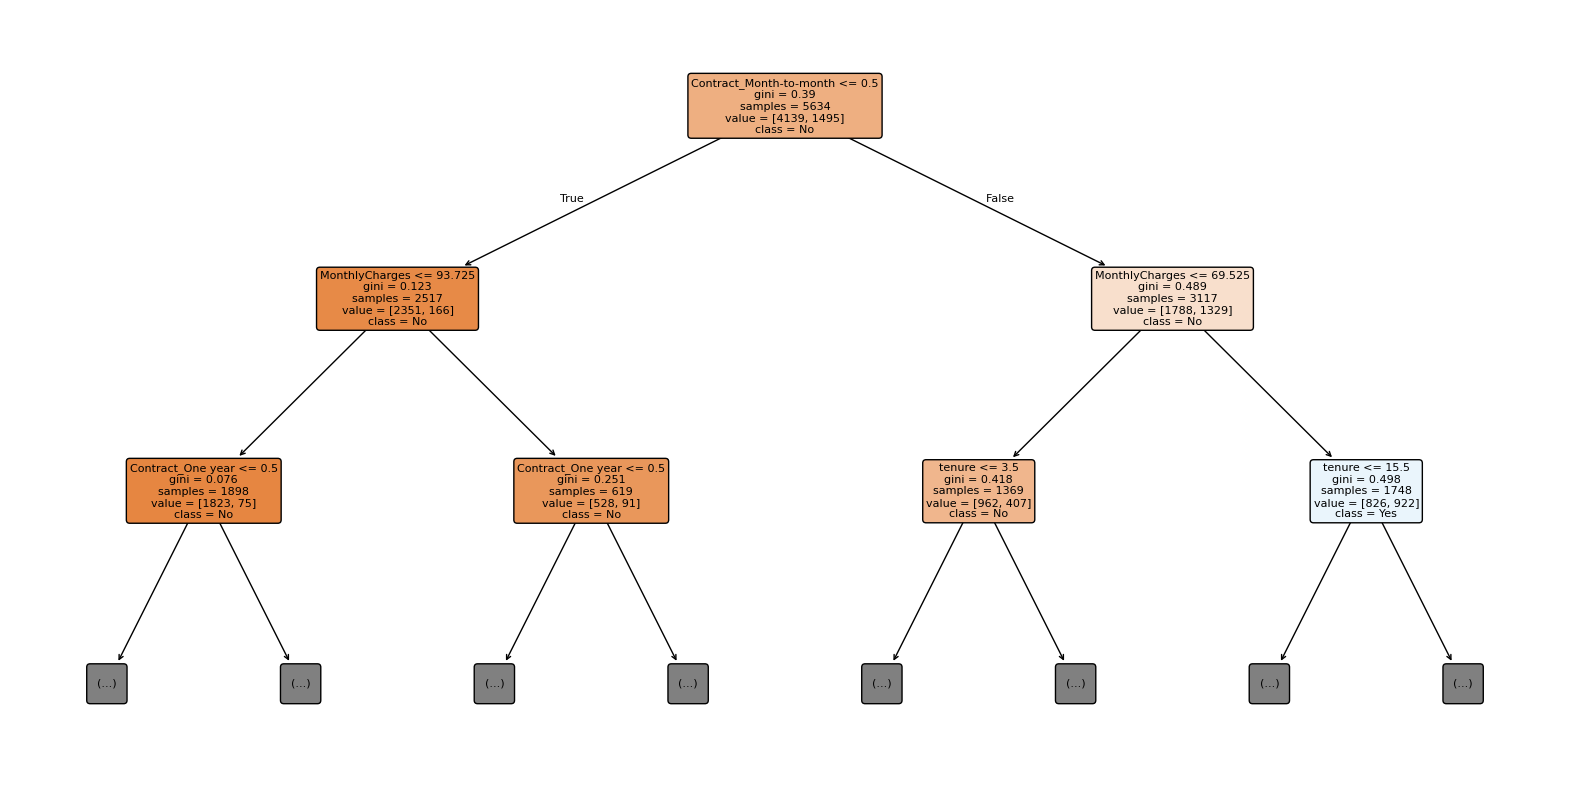

In [51]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    final_model,
    feature_names=train_val_X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=2
)

plt.show()

To improve interpretability, only the upper levels of the decision tree are visualized. These top splits capture the main segmentation logic learned by the model, while deeper branches represent more detailed and localized patterns.

The root node shows that contract type is the primary driver of churn. The first split separates customers on month-to-month contracts from those on longer-term agreements, confirming that contract structure is the dominant factor in the model.

Among customers not on month-to-month contracts, the next important variable is monthly charges. Customers with lower monthly charges form a relatively stable group, while those with higher charges show more variation in churn risk. Within these groups, one-year contracts provide an additional layer of separation, indicating that contract duration continues to matter even among customers who are already on longer-term plans.

For customers on month-to-month contracts, monthly charges again emerge as a key differentiator. Within this segment, the model then uses tenure to further separate customers, showing that churn risk is especially sensitive to customer lifecycle stage among less contractually committed customers.

In particular, customers on month-to-month contracts with short tenure appear substantially more vulnerable to churn, while longer-tenured customers remain more heterogeneous and are further segmented by tenure thresholds. This suggests that the combination of low contractual commitment, pricing, and early-stage customer status is especially important in identifying high-risk customers.

Overall, the tree reveals a clear hierarchical structure: contract type defines the primary split, monthly charges provide the next level of segmentation, and tenure further refines churn risk within these groups. In some branches, one-year contract status adds additional discrimination, reinforcing the importance of contractual commitment in shaping customer retention.

We can now investigate feature importance more closely.

### Feature Importance

In [52]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": train_val_X.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
6,Contract_Month-to-month,0.510735
14,tenure,0.199464
15,MonthlyCharges,0.192417
12,PaymentMethod_bin_3_Electronic check,0.029808
9,PaperlessBilling_No,0.015559
16,AdditionalInternetServicesCount,0.014051
7,Contract_One year,0.013595
17,StreamingServicesCount,0.010117
0,SeniorCitizenRelevel_No,0.009549
11,PaymentMethod_bin_3_Automatic,0.002892


Feature importance analysis indicates that several variables, including `Partner` and `Dependents`, have zero importance in the fitted decision tree model. These features are not used in any splits, suggesting that they do not provide additional predictive value beyond the variables already included in the model.

This behavior is expected, as stronger predictors such as contract type, tenure, and monthly charges capture the primary structure of churn risk. As a result, these features become redundant in the presence of more informative variables.

To simplify the model and improve interpretability, `Partner` and `Dependents` are removed from the feature set. This reduction does not affect model performance, as confirmed by validation results, and leads to a more parsimonious representation of the data.


### Feature Selection Based on Model Importance

To further simplify the model and improve interpretability, feature importance derived from the trained decision tree is used to identify variables that do not contribute to predictive performance.

The importance scores show that both categories of the `Dependents` and `Partner` features have zero importance, indicating that the model does not use these variables in any of its decision splits. In tree-based models, this directly implies that the features provide no additional information beyond what is already captured by other variables.

This result is consistent with earlier findings, where contract type, tenure, and monthly charges dominate the model and explain most of the variation in churn behavior. As a result, `Dependents` and `Partner` become redundant in the presence of these stronger predictors.

Based on this observation, both features are removed from the feature set. This reduction simplifies the input space without affecting model performance, while improving clarity and interpretability of the final model.

The model is then retrained using the reduced feature set to confirm that predictive performance remains unchanged.

In [53]:
categorical_reduced_cols = ['SeniorCitizenRelevel',
                    'Contract',
                    'PaperlessBilling',
                    'PaymentMethod_bin_3']

target_col = "Churn"

numerical_cols = ['tenure', 
                  'MonthlyCharges', 
                  'AdditionalInternetServicesCount', 
                  'StreamingServicesCount']   

categorical_orders = { "SeniorCitizenRelevel": ["No", "Yes"], 
                      "PaperlessBilling": ["No", "Yes"], 
                      "Contract": ["Month-to-month", "One year", "Two year"] }

train_X_reduced, train_y_reduced = prepare_tree_features(
    df=train_df.drop(["Dependents", "Partner"]), #full train dataset without Dependents and partner
    categorical_cols=categorical_reduced_cols,
    numerical_cols=numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col
)

In [54]:
from sklearn.tree import DecisionTreeClassifier

final_model_reduced = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_leaf=25,
    min_samples_split=8,
    random_state=42
)

final_model_reduced.fit(train_X_reduced, train_y_reduced)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",25
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [55]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": train_X_reduced.columns,
    "importance": final_model_reduced.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
2,Contract_Month-to-month,0.510735
10,tenure,0.199464
11,MonthlyCharges,0.192417
8,PaymentMethod_bin_3_Electronic check,0.029808
12,AdditionalInternetServicesCount,0.014051
4,Contract_Two year,0.013595
6,PaperlessBilling_Yes,0.011084
13,StreamingServicesCount,0.010117
0,SeniorCitizenRelevel_No,0.009549
5,PaperlessBilling_No,0.006290


### Feature Selection Based on Model Importance

Feature importance analysis revealed that the `Dependents` and `Partner` variables were not used by the decision tree, with all encoded categories exhibiting zero importance. This indicates that these features do not contribute to any splits and provide no additional predictive signal.

To validate this observation, the model was retrained after removing both `Dependents` and `Partner`. The resulting model retained the same optimal hyperparameters and achieved an equivalent PR-AUC score, confirming that these features have no impact on predictive performance.

Based on this result, `Dependents` and `Partner` are excluded from the final decision tree model, simplifying the feature space without affecting model quality.

In [56]:
### Store the model for the consistency

import pickle

model_package = {
    # model
    "model": final_model_reduced,
    # data preparation setup
    "categorical_cols":categorical_reduced_cols,
    "numerical_cols":numerical_cols,
    "categorical_orders":categorical_orders,
    "target_col":target_col,
    "reference_columns": train_X_reduced.columns.tolist()
}

with open("./models/decision_tree_final.pkl", "wb") as f:
    pickle.dump(model_package, f)

## Test Set Evaluation

After selecting the final model through cross-validation and hyperparameter tuning, performance is evaluated on a held-out test dataset. This dataset was not used at any stage of model training or model selection, ensuring that the evaluation provides an unbiased estimate of generalization performance.

The test set serves as a proxy for unseen, real-world data and allows us to assess how well the model is expected to perform in practice. While cross-validation was used to guide model selection and hyperparameter tuning, it remains an internal validation procedure. The test set therefore represents the final and independent benchmark for model performance.

Evaluation focuses on multiple metrics, including ROC-AUC, PR-AUC, accuracy, precision, recall, and F1 score, providing a comprehensive view of both ranking performance and classification behavior. Particular emphasis is placed on PR-AUC, given the class imbalance and the importance of correctly identifying churners.

This evaluation step confirms whether the performance observed during cross-validation translates to truly unseen data and provides the basis for final model assessment and comparison with alternative modeling approaches.

In [57]:
from src.utils.classification_metrics import compute_classification_metrics

categorical_reduced_cols = ['SeniorCitizenRelevel',
                    'Contract',
                    'PaperlessBilling',
                    'PaymentMethod_bin_3']

target_col = "Churn"

numerical_cols = ['tenure', 
                  'MonthlyCharges', 
                  'AdditionalInternetServicesCount', 
                  'StreamingServicesCount']   

categorical_orders = { "SeniorCitizenRelevel": ["No", "Yes"], 
                      "Partner": ["No", "Yes"], 
                      "PaperlessBilling": ["No", "Yes"], 
                      "Contract": ["Month-to-month", "One year", "Two year"] }

test_X_reduced, test_y_reduced = prepare_tree_features(
    df=test_df,
    categorical_cols=categorical_reduced_cols,
    numerical_cols=numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col,
    reference_columns=train_X_reduced.columns.tolist()
)

In [58]:
test_probs = final_model_reduced.predict_proba(test_X_reduced)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

metrics = compute_classification_metrics(
    y_true=test_y_reduced,
    y_pred=test_preds,
    y_prob=test_probs
)


In [59]:
metrics_df = (
    pd.DataFrame([metrics])
    .drop(columns=["tp", "tn", "fp", "fn"])
    .round(4)
)

metrics_df

,accuracy,precision,recall,f1,auc,pr_auc
0,0.7885,0.6258,0.5053,0.5592,0.8307,0.6297


In [60]:
conf_matrix = pd.DataFrame(
    [[metrics["tn"], metrics["fp"]],
     [metrics["fn"], metrics["tp"]]],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

conf_matrix

,Pred 0,Pred 1
Actual 0,922,113
Actual 1,185,189


The decision tree model achieves an accuracy of approximately 78.9%. Given the class imbalance in the dataset, accuracy alone is not a sufficient measure of performance and should be interpreted alongside other metrics.

The model demonstrates a trade-off between identifying churners and limiting false positives. A recall of 0.505 indicates that just over half of churners are correctly identified, while a precision of 0.626 shows that a clear majority of predicted churners are correctly classified. This reflects a relatively balanced model with a slight emphasis on precision.

The confusion matrix highlights this behavior:

* True Negatives: 922
* False Positives: 113
* False Negatives: 185
* True Positives: 189

This indicates that the model maintains a moderate number of false positives while still missing a portion of churners. Compared to earlier iterations, the model shows a slight improvement in recall, suggesting better identification of at-risk customers without substantially increasing false positives.

From a ranking perspective, the model performs strongly. The ROC-AUC of 0.831 indicates good discriminative ability, meaning that churners are generally ranked above non-churners. The PR-AUC of 0.630 confirms solid performance in identifying the minority class and represents a meaningful improvement over earlier validation results.

Overall, the decision tree provides a flexible, non-linear representation of customer behavior, capturing interactions and segment-level patterns. Its classification behavior reflects a balanced trade-off between precision and recall, making it suitable for applications where both accurate targeting and control of false positives are important.

As with previous stages, the predicted probabilities remain the most valuable output, enabling the model to be used as a prioritization tool rather than relying solely on a fixed classification threshold.

## Executive Summary

The objective of this model is to identify customers at risk of churning and prioritize them based on their likelihood of leaving. Rather than focusing solely on binary classification, the model estimates churn probabilities, enabling flexible and actionable decision-making.

The decision tree model achieves solid predictive performance, with a ROC-AUC of 0.831 and PR-AUC of 0.630 on the test set. These results indicate that the model is effective at distinguishing between higher-risk and lower-risk customers, particularly in the presence of class imbalance.

From a classification perspective, the model reflects a balanced behavior with a slight emphasis on precision. It correctly identifies just over half of churners (recall ≈ 0.51) while achieving a precision of approximately 0.63, meaning that predicted churners are more likely to truly churn. This makes the model suitable for use cases where both accurate targeting and reasonable control of false positives are important.

Beyond predictive performance, the model provides a clear segmentation of customer behavior. Contract type emerges as the primary driver of churn, with customers on month-to-month contracts exhibiting significantly higher risk. Within this group, monthly charges and tenure further differentiate risk levels, highlighting the role of pricing sensitivity and customer lifecycle stage in churn behavior.

In practice, the model is best used as a prioritization tool. By ranking customers according to predicted churn probability, retention efforts can be focused on those most likely to leave, improving the efficiency and effectiveness of intervention strategies.

Overall, the decision tree model provides a flexible, non-linear representation of customer behavior, capturing key interactions and segment-level patterns while maintaining strong interpretability.